# Proximity and Knowledge Spillovers
## Measuring the University–Industry Link via Co-Authorship Analysis

**Objective:** Identify and quantify university–industry collaborations in HealthTech using Scopus publication data.  
**Methodology:** Co-authorship analysis — filtering for papers jointly authored by at least one university *and* one private company.  
**Hypothesis:** We expect a strong **home bias**: firms prefer to collaborate with universities in their own country (or region), supporting the theory that face-to-face interaction is crucial for transferring complex tacit knowledge.

---
### Outline
1. Data loading & cleaning  
2. Institution classification (university vs. company)  
3. Identifying university–industry co-authored papers  
4. Home-bias analysis (same-country collaborations)  
5. Top collaborating institution pairs  
6. Collaboration network visualization  
7. Temporal evolution of U–I collaborations  
8. Country-level choropleth maps  
9. Spatial autocorrelation (Moran's I + LISA)  
10. Cross-country collaboration matrix & proximity effect  
11. Summary & conclusions

## 0. Install & Import Dependencies

In [1]:
# Install spatial analysis packages (skip silently if no network)
import subprocess, sys

PACKAGES = ['geopandas', 'libpysal', 'esda', 'splot', 'networkx', 'matplotlib', 'seaborn']

for pkg in PACKAGES:
    try:
        result = subprocess.run(
            [sys.executable, '-m', 'pip', 'install', pkg, '-q'],
            capture_output=True, text=True, timeout=60
        )
        if result.returncode != 0:
            print(f'  Warning: could not install {pkg} — {result.stderr.strip()[:80]}')
    except Exception as e:
        print(f'  Skipping {pkg}: {e}')


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import geopandas as gpd
import networkx as nx
import warnings
warnings.filterwarnings('ignore')

# Plotting style
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'axes.titlesize': 13})
sns.set_theme(style='whitegrid')

print('All libraries loaded successfully.')

All libraries loaded successfully.


## 1. Load & Inspect the Dataset

In [3]:
df = pd.read_csv('scopus_data.csv')
print(f'Dataset shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head(3)

Dataset shape: (987, 30)
Columns: ['Authors', 'Author full names', 'Author(s) ID', 'Title', 'Year', 'Source title', 'Volume', 'Issue', 'Art. No.', 'Page start', 'Page end', 'Cited by', 'DOI', 'Link', 'Affiliations', 'Authors with affiliations', 'Correspondence Address', 'Editors', 'Publisher', 'ISSN', 'ISBN', 'CODEN', 'PubMed ID', 'Language of Original Document', 'Abbreviated Source Title', 'Document Type', 'Publication Stage', 'Open Access', 'Source', 'EID']


,Authors,Author full names,Author(s) ID,Title,Year,Source title,Volume,Issue,Art. No.,Page start,...,ISBN,CODEN,PubMed ID,Language of Original Document,Abbreviated Source Title,Document Type,Publication Stage,Open Access,Source,EID
0,Youderian A.R.; Greene A.T.; Polakovic S.V.; D...,"Youderian, Ari R. (23988193100); Greene, Alexa...",23988193100; 57014375300; 57015590000; 5815494...,Two-year clinical outcomes and complication ra...,2023,Journal of Shoulder and Elbow Surgery,32,12,NaN,2519,...,NaN,JSESB,37348780.0,English,J. Shoulder Elbow Surg.,Article,Final,NaN,Scopus,2-s2.0-85169164891
1,Kim H.; You J.M.; Hwang M.; Kyung K.-U.; Kwon ...,"Kim, Hansoul (57206210777); You, Jae Min (5721...",57206210777; 57212209859; 57191246140; 7004203...,Sigmoidal Auxiliary Tendon-Driven Mechanism Re...,2023,Soft Robotics,10,2,NaN,234,...,NaN,NaN,35763840.0,English,Soft Robotics,Article,Final,NaN,Scopus,2-s2.0-85152635002
2,Saleh M.; Pascual F.; Ghallab M.; Wu A.G.R.; C...,"Saleh, Mansour (57737949000); Pascual, Franco ...",57737949000; 57223167470; 56115703600; 5721925...,Factors Associated with and Impact of Open Con...,2024,Annals of Surgical Oncology,31,9,NaN,5615,...,NaN,ASONF,38879668.0,English,Ann. Surg. Oncol.,Article,Final,NaN,Scopus,2-s2.0-85200313661


In [4]:
# Basic data quality check
print('=== DATA QUALITY CHECK ===')
print(f"Total papers: {len(df)}")
print(f"Missing Affiliations: {df['Affiliations'].isna().sum()} ({df['Affiliations'].isna().mean()*100:.1f}%)")
print(f"Year range: {df['Year'].min()} – {df['Year'].max()}")
print(f"Unique document types: {df['Document Type'].unique()}")

=== DATA QUALITY CHECK ===
Total papers: 987
Missing Affiliations: 0 (0.0%)
Year range: 2020 – 2024
Unique document types: ['Article' 'Conference paper' 'Short survey' 'Review' 'Book chapter'
 'Letter' 'Editorial' 'Erratum' 'Note' 'Retracted' 'Book']


## 2. Institution Classification

Each semicolon-separated affiliation string is parsed and classified as:
- **`univ`**: universities, institutes, colleges, academies, etc.
- **`company`**: private firms (Inc., Ltd., Corp., GmbH, etc.)
- **`hospital`**: hospitals and medical centres (often bridges academia and industry)
- **`other`**: government labs, NGOs, etc.

In [5]:
import re

# ── Keyword lists ──────────────────────────────────────────────────────────────
UNIVERSITY_KEYWORDS = [
    'university', 'université', 'universität', 'universidad', 'università',
    'universidade', 'college', 'institute of technology', 'polytechnic',
    'école', 'ecole', 'school of', 'faculty', 'akademi', 'akademia',
    'academy', 'hochschule', 'faculdade'
]

RESEARCH_INST_KEYWORDS = [
    'research center', 'research centre', 'research institute',
    'national institute', 'cnrs', 'inserm', 'inria', 'fraunhofer',
    'helmholtz', 'max planck', 'csiro', 'nist', 'nih ', ' mrc '
]

COMPANY_KEYWORDS = [
    ' inc', ' inc.', ' ltd', ' ltd.', ' corp', ' corp.', ' corporation',
    ' llc', ' llc.', ' gmbh', ' s.a.', ' s.a.s', ' b.v.', ' n.v.',
    ' ag ', ' plc', ' spa', ' srl', ' sarl', ' bvba', ' kk',
    ' co.', ' co,', 'medtronic', 'siemens', 'philips', 'johnson & johnson',
    'stryker', 'boston scientific', 'abbott', 'zimmer', 'becton',
    'technologies', 'therapeutics', 'pharmaceuticals', 'biotech',
    'medical systems', 'life sciences', 'diagnostics'
]

HOSPITAL_KEYWORDS = [
    'hospital', 'clinic', 'medical center', 'medical centre',
    'health system', 'healthcare', 'centre hospitalier', 'chu ', 'chru'
]


def classify_institution(text: str) -> str:
    """Classify a single affiliation string into a category."""
    t = text.lower()
    if any(kw in t for kw in UNIVERSITY_KEYWORDS):
        return 'univ'
    if any(kw in t for kw in HOSPITAL_KEYWORDS):
        return 'hospital'
    if any(kw in t for kw in RESEARCH_INST_KEYWORDS):
        return 'research_inst'
    if any(kw in t for kw in COMPANY_KEYWORDS):
        return 'company'
    return 'other'


def parse_affiliations(affiliation_text: str):
    """
    Parse the full affiliation field and return:
      institutions : list[str]  – one entry per semicolon-separated block
      types        : list[str]  – classification for each institution
    """
    if pd.isna(affiliation_text):
        return [], []
    parts = [p.strip() for p in affiliation_text.split(';') if p.strip()]
    types = [classify_institution(p) for p in parts]
    return parts, types


df['institutions'], df['types'] = zip(*df['Affiliations'].apply(parse_affiliations))

# Convenience boolean flags
df['has_univ']    = df['types'].apply(lambda t: 'univ' in t)
df['has_company'] = df['types'].apply(lambda t: 'company' in t)
df['ui_collab']   = df['has_univ'] & df['has_company']   # University–Industry collaboration

print('=== AFFILIATION CLASSIFICATION RESULTS ===')
print(f"Papers with ≥1 university affiliation : {df['has_univ'].sum():>5}")
print(f"Papers with ≥1 company affiliation    : {df['has_company'].sum():>5}")
print(f"Papers with BOTH (U–I co-authored)    : {df['ui_collab'].sum():>5} ({df['ui_collab'].mean()*100:.1f}%)")

=== AFFILIATION CLASSIFICATION RESULTS ===
Papers with ≥1 university affiliation :   920
Papers with ≥1 company affiliation    :   721
Papers with BOTH (U–I co-authored)    :   670 (67.9%)


## 3. Country Extraction

We extract the country from each affiliation block using the **last comma-separated token** of the string (Scopus convention: `Author, Affiliation, City, Country`).

In [6]:
from typing import Optional

# ── Country name normalisations ───────────────────────────────────────────────
COUNTRY_ALIASES = {
    'usa': 'United States', 'u.s.a.': 'United States',
    'united states of america': 'United States',
    'uk': 'United Kingdom', 'great britain': 'United Kingdom',
    'england': 'United Kingdom', 'scotland': 'United Kingdom',
    'wales': 'United Kingdom', 'northern ireland': 'United Kingdom',
    "people's republic of china": 'China', 'p.r. china': 'China',
    'republic of korea': 'South Korea', 'korea': 'South Korea',
    'russian federation': 'Russia',
    'taiwan, province of china': 'Taiwan',
    'iran, islamic republic of': 'Iran',
    'czech republic': 'Czechia',
    'viet nam': 'Vietnam',
    'syrian arab republic': 'Syria',
}

KNOWN_COUNTRIES = {
    'Afghanistan','Albania','Algeria','Argentina','Armenia','Australia','Austria',
    'Azerbaijan','Bahrain','Bangladesh','Belgium','Bolivia','Bosnia','Brazil',
    'Bulgaria','Cambodia','Cameroon','Canada','Chile','China','Colombia','Croatia',
    'Cuba','Cyprus','Czechia','Denmark','Ecuador','Egypt','Estonia','Ethiopia',
    'Finland','France','Georgia','Germany','Ghana','Greece','Guatemala','Hong Kong',
    'Hungary','Iceland','India','Indonesia','Iran','Iraq','Ireland','Israel',
    'Italy','Japan','Jordan','Kazakhstan','Kenya','Kuwait','Latvia','Lebanon',
    'Lithuania','Luxembourg','Malaysia','Mexico','Morocco','Netherlands',
    'New Zealand','Nigeria','Norway','Oman','Pakistan','Peru','Philippines',
    'Poland','Portugal','Qatar','Romania','Russia','Saudi Arabia','Serbia',
    'Singapore','Slovakia','Slovenia','South Africa','South Korea','Spain',
    'Sri Lanka','Sweden','Switzerland','Taiwan','Thailand','Tunisia','Turkey',
    'Ukraine','United Arab Emirates','United Kingdom','United States','Uruguay',
    'Uzbekistan','Venezuela','Vietnam','Zimbabwe',
}


def extract_country_from_affiliation(affil: str) -> Optional[str]:
    """Extract the country from a single affiliation block."""
    if not affil or not isinstance(affil, str):
        return None
    token = affil.split(',')[-1].strip().strip('.')
    token_lower = token.lower()
    if token_lower in COUNTRY_ALIASES:
        return COUNTRY_ALIASES[token_lower]
    token_title = token.title()
    if token_title in KNOWN_COUNTRIES:
        return token_title
    for c in KNOWN_COUNTRIES:
        if c.lower() == token_lower:
            return c
    return None


def extract_countries_list(affiliation_text: str) -> list:
    """Return a list of countries, one per semicolon-separated affiliation block."""
    if pd.isna(affiliation_text):
        return []
    parts = [p.strip() for p in affiliation_text.split(';') if p.strip()]
    return [extract_country_from_affiliation(p) for p in parts]


df['countries'] = df['Affiliations'].apply(extract_countries_list)

# Sanity check: lengths should match 'institutions' list
length_match = df.apply(lambda r: len(r['institutions']) == len(r['countries']), axis=1).all()
print(f'Country list length matches institutions list: {length_match}')

sample = df[df['ui_collab']]['countries'].dropna().head(3)
print('Sample country lists for U-I papers:')
for s in sample:
    print(' ', s)


Country list length matches institutions list: True
Sample country lists for U-I papers:
  ['United States', 'United States', 'United States', 'United States', 'United States', 'United States', 'Brazil', 'United States', 'France', 'United States']
  ['France', 'Singapore', 'Italy', 'Italy', 'Italy', 'Vietnam', 'Japan', 'France', 'Brazil', 'Germany', 'Norway', 'China', 'Italy', 'Italy', 'Italy', 'Singapore', 'United States', 'Slovenia', 'Italy', 'South Korea', 'South Korea', 'United States', 'Spain', 'Spain', 'Spain', 'Russia', 'Spain', 'Spain', 'South Korea', 'Spain', 'United Kingdom', 'Hong Kong', 'Hong Kong', 'Belgium', 'Italy', 'United States', 'United States', 'Japan', 'Spain', 'China', 'Italy', 'Italy', 'Italy', 'Italy', 'Italy', 'Taiwan', 'China', 'Japan', 'United States', 'Taiwan', 'Hong Kong', 'United Kingdom', 'France', 'South Korea', 'Singapore', 'Singapore', 'Norway', 'Italy', 'Italy']
  ['China', 'China', 'Hong Kong', 'China', 'Hong Kong', 'China']


## 4. Home-Bias Analysis

**Definition of home bias:** A U–I co-authored paper exhibits *home bias* when at least one university–company pair within the paper shares the **same country**.

This is the core test of our Chapter 2 hypothesis.

In [7]:
def check_home_bias(row):
    """
    Returns:
      True   – at least one (university, company) pair shares a country
      False  – U-I paper but no same-country pair found
      None   – paper does not have both institution types
    """
    types     = row['types']
    countries = row['countries']

    if not isinstance(types, list) or not isinstance(countries, list):
        return None

    n = min(len(types), len(countries))
    types_n, countries_n = types[:n], countries[:n]

    univ_countries    = {countries_n[i] for i, t in enumerate(types_n)
                         if t == 'univ' and countries_n[i]}
    company_countries = {countries_n[i] for i, t in enumerate(types_n)
                         if t == 'company' and countries_n[i]}

    if not univ_countries or not company_countries:
        return None

    return bool(univ_countries & company_countries)


df['home_bias'] = df.apply(check_home_bias, axis=1)

# Only U-I papers
ui_df = df[df['ui_collab']].copy()
valid = ui_df['home_bias'].notna()

total_ui = int(valid.sum())

if total_ui == 0:
    print('WARNING: No valid U-I papers found for home-bias analysis.')
    pct_same = 0.0
    same_country = 0
    cross_country = 0
else:
    same_country  = int(ui_df.loc[valid, 'home_bias'].sum())
    cross_country = total_ui - same_country
    pct_same      = same_country / total_ui * 100

print('=' * 55)
print('   HOME-BIAS ANALYSIS — CORE RESULT')
print('=' * 55)
print(f'  U-I co-authored papers (valid):  {total_ui:>5}')
print(f'  Same-country collaborations:     {same_country:>5}  ({pct_same:.1f}%)')
print(f'  Cross-country collaborations:    {cross_country:>5}  ({100-pct_same:.1f}%)')
print('=' * 55)
if pct_same > 60:
    print('-> RESULT SUPPORTS the home-bias hypothesis.')
else:
    print('-> Result does NOT strongly support the home-bias hypothesis.')


   HOME-BIAS ANALYSIS — CORE RESULT
  U-I co-authored papers (valid):    662
  Same-country collaborations:       559  (84.4%)
  Cross-country collaborations:      103  (15.6%)
-> RESULT SUPPORTS the home-bias hypothesis.


## 5. Top Collaborating Institution Pairs

We extract the most frequent **(university, company)** institution pairs, providing concrete examples of the knowledge-spillover channels identified in the literature.

In [8]:
from itertools import product
from collections import Counter

def extract_ui_pairs(row):
    """Return all (university_name, company_name) pairs in a paper."""
    institutions = row['institutions']
    types        = row['types']
    if not institutions or not types:
        return []
    n = min(len(institutions), len(types))
    univs     = [institutions[i][:60] for i in range(n) if types[i] == 'univ']
    companies = [institutions[i][:60] for i in range(n) if types[i] == 'company']
    return list(product(univs, companies))


pair_counter = Counter()
for _, row in ui_df.iterrows():
    pair_counter.update(extract_ui_pairs(row))

top_pairs = pd.DataFrame(
    pair_counter.most_common(20),
    columns=['(University, Company)', 'Co-authored Papers']
)

print('=== TOP 20 UNIVERSITY–COMPANY COLLABORATION PAIRS ===')
print(top_pairs.to_string(index=False))

=== TOP 20 UNIVERSITY–COMPANY COLLABORATION PAIRS ===
                                                                                                       (University, Company)  Co-authored Papers
(Department of Surgery, Campus Charité Mitte and Campus Virch, Institute of Health Research of Navarra (IdisNA), Pamplona, )                   9
(Faculty of Hepatopancreatobiliary Surgery, The First Medical, Institute of Health Research of Navarra (IdisNA), Pamplona, )                   9
(Department of General Surgery, CHA Bundang Medical Center, C, Institute of Health Research of Navarra (IdisNA), Pamplona, )                   9
(Hepatobiliary Surgery and Liver Transplantation Unit, Biocru, Institute of Health Research of Navarra (IdisNA), Pamplona, )                   9
(Division of Hepatopancreatobiliary Surgery, Department of Su, Institute of Health Research of Navarra (IdisNA), Pamplona, )                   9
(Department of Hepatopancreatobiliary and Liver Transplant Su, Institute of 

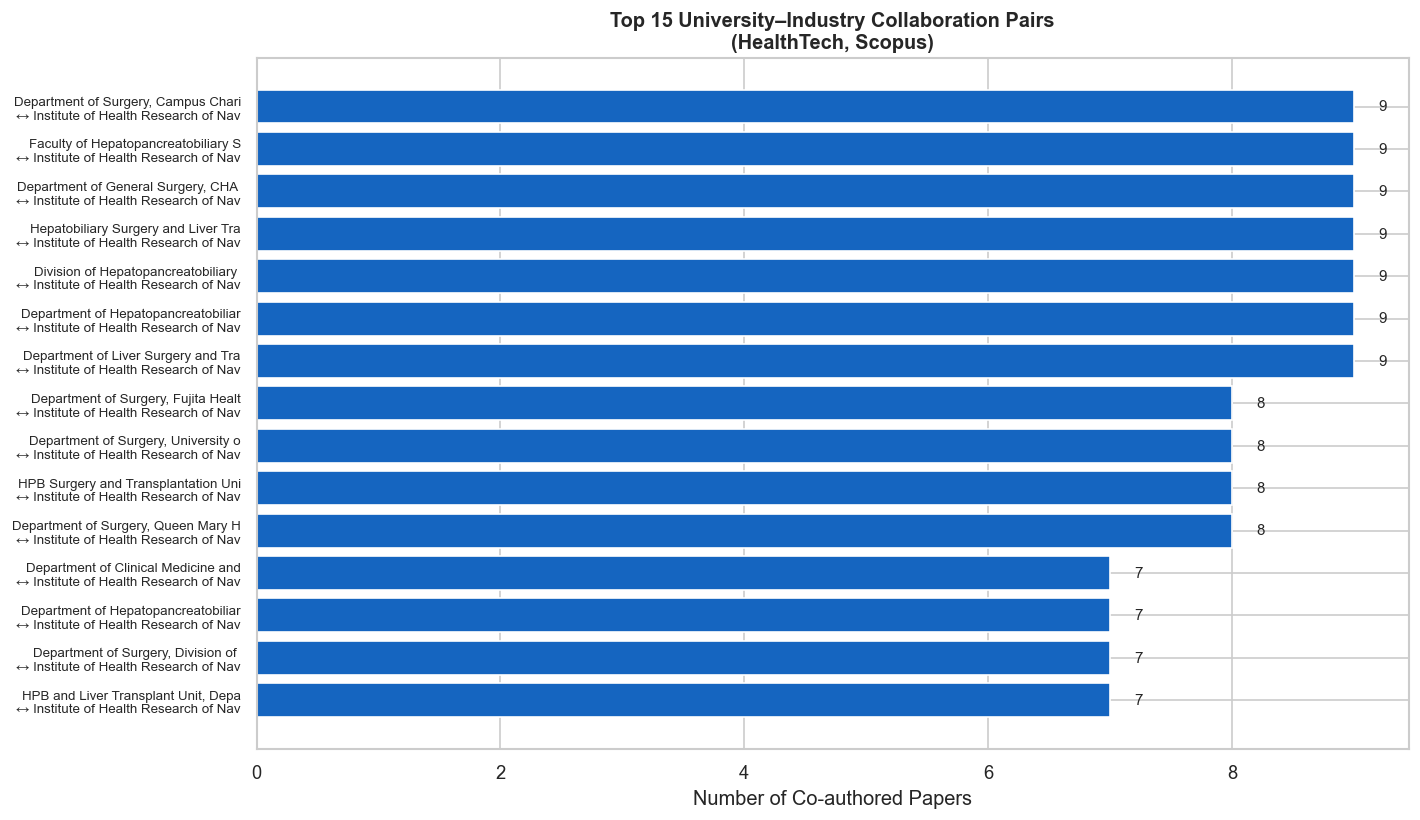

In [9]:
# Visualise top 15 pairs
top15 = top_pairs.head(15).copy()
top15['label'] = top15['(University, Company)'].apply(lambda x: f"{x[0][:35]}\n↔ {x[1][:35]}")

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(range(len(top15)), top15['Co-authored Papers'], color='#1565C0', edgecolor='white')
ax.set_yticks(range(len(top15)))
ax.set_yticklabels(top15['label'], fontsize=8)
ax.set_xlabel('Number of Co-authored Papers')
ax.set_title('Top 15 University–Industry Collaboration Pairs\n(HealthTech, Scopus)', fontweight='bold')
ax.invert_yaxis()
for bar, val in zip(bars, top15['Co-authored Papers']):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=9)
plt.tight_layout()
plt.savefig('top_pairs.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Top Collaborating Countries

Which countries produce the most U–I co-authored papers, and what share stays domestic?

In [10]:
# Build expanded table: one row per (paper, institution-type, country)
rows = []
for _, row in df.iterrows():
    types     = row['types']
    countries = row['countries']
    if not isinstance(types, list) or not isinstance(countries, list):
        continue
    n = min(len(types), len(countries))
    for i in range(n):
        if countries[i]:
            rows.append({
                'EID':          row['EID'],
                'Year':         row['Year'],
                'ui_collab':    row['ui_collab'],
                'inst_type':    types[i],
                'country':      countries[i],
            })

expanded = pd.DataFrame(rows)

# Count papers per country (deduplicate per paper)
papers_per_country = (
    expanded.drop_duplicates(subset=['EID', 'country'])
    .groupby('country')['EID'].count()
    .rename('papers_total')
)

ui_papers_per_country = (
    expanded[expanded['ui_collab']]
    .drop_duplicates(subset=['EID', 'country'])
    .groupby('country')['EID'].count()
    .rename('papers_ui')
)

country_stats = pd.concat([papers_per_country, ui_papers_per_country], axis=1).fillna(0)
country_stats['ui_share'] = country_stats['papers_ui'] / country_stats['papers_total'] * 100
country_stats = country_stats.sort_values('papers_ui', ascending=False)

print(f'Countries with data: {len(country_stats)}')
print(country_stats.head(15).to_string())

Countries with data: 75
                papers_total  papers_ui   ui_share
country                                           
United States            366      277.0  75.683060
China                    267      201.0  75.280899
Germany                  210      108.0  51.428571
United Kingdom           105       83.0  79.047619
Japan                     79       66.0  83.544304
South Korea               72       54.0  75.000000
Italy                     66       46.0  69.696970
France                    53       40.0  75.471698
Hong Kong                 62       35.0  56.451613
Canada                    35       29.0  82.857143
Spain                     37       28.0  75.675676
Australia                 33       26.0  78.787879
Austria                   36       26.0  72.222222
Belgium                   35       26.0  74.285714
Qatar                     30       26.0  86.666667


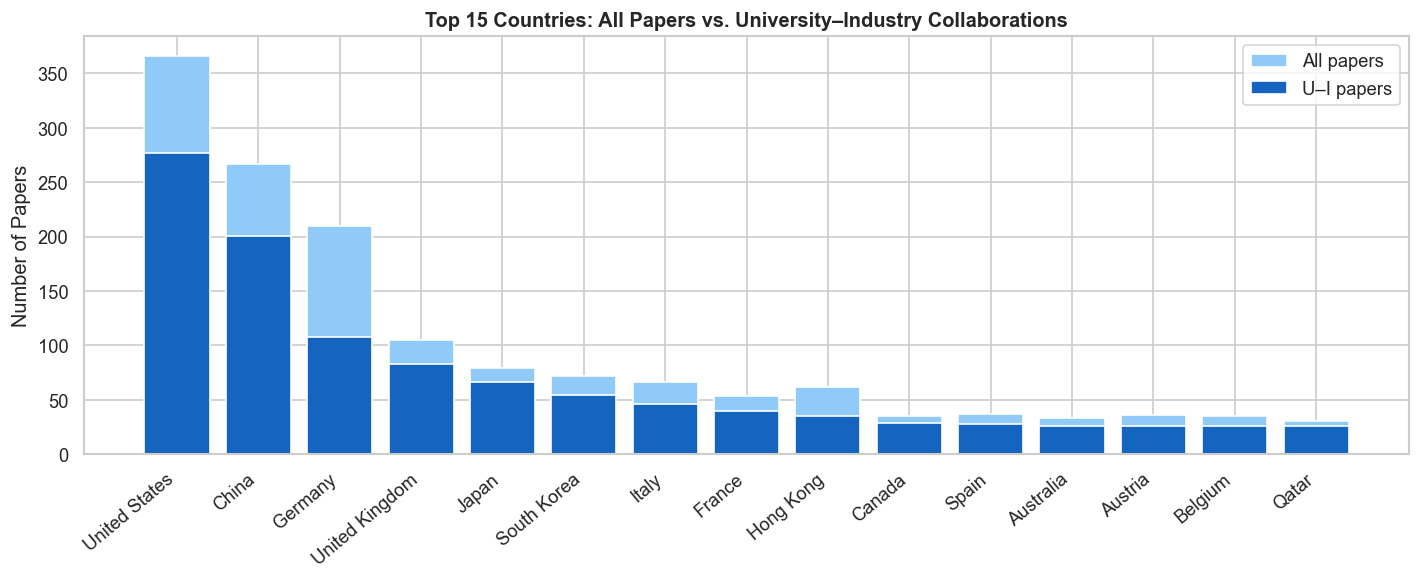

In [11]:
# Bar chart: top 15 countries by U–I papers
top_countries = country_stats.head(15)

fig, ax = plt.subplots(figsize=(12, 5))
x = range(len(top_countries))
ax.bar(x, top_countries['papers_total'], label='All papers', color='#90CAF9', edgecolor='white')
ax.bar(x, top_countries['papers_ui'],    label='U–I papers', color='#1565C0', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(top_countries.index, rotation=40, ha='right')
ax.set_ylabel('Number of Papers')
ax.set_title('Top 15 Countries: All Papers vs. University–Industry Collaborations', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('country_ui_papers.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Cross-Country Collaboration Matrix

For U–I papers where the university and company are in *different* countries, we build a cross-country collaboration matrix to reveal the most common international knowledge corridors.

In [12]:
# Build cross-country (university_country, company_country) pairs
cross_pairs = []

for _, row in ui_df.iterrows():
    types     = row['types']
    countries = row['countries']
    if not isinstance(types, list) or not isinstance(countries, list):
        continue
    n = min(len(types), len(countries))
    univ_countries = [(i, countries[i]) for i in range(n)
                       if types[i] == 'univ' and countries[i]]
    comp_countries = [(i, countries[i]) for i in range(n)
                       if types[i] == 'company' and countries[i]]
    for (_, uc), (_, cc) in product(univ_countries, comp_countries):
        if uc != cc:   # cross-country only
            cross_pairs.append((uc, cc))

cross_df    = pd.DataFrame(cross_pairs, columns=['univ_country', 'comp_country'])
cross_counts = (
    cross_df.groupby(['univ_country', 'comp_country'])
    .size()
    .reset_index(name='n_collabs')
    .sort_values('n_collabs', ascending=False)
)

print(f'Total cross-country U–I pairs: {len(cross_counts)}')
print('Top 15 cross-country corridors:')
print(cross_counts.head(15).to_string(index=False))

Total cross-country U–I pairs: 245
Top 15 cross-country corridors:
  univ_country   comp_country  n_collabs
         Italy          Spain         98
United Kingdom  United States         70
   South Korea          Spain         46
 United States United Kingdom         39
         China          Spain         37
 United States          Spain         30
         Italy United Kingdom         24
     Hong Kong          Spain         23
United Kingdom          Spain         22
         Italy        Germany         20
         China        Germany         19
 United States        Germany         19
     Hong Kong          China         19
        Canada  United States         19
        Norway        Germany         18


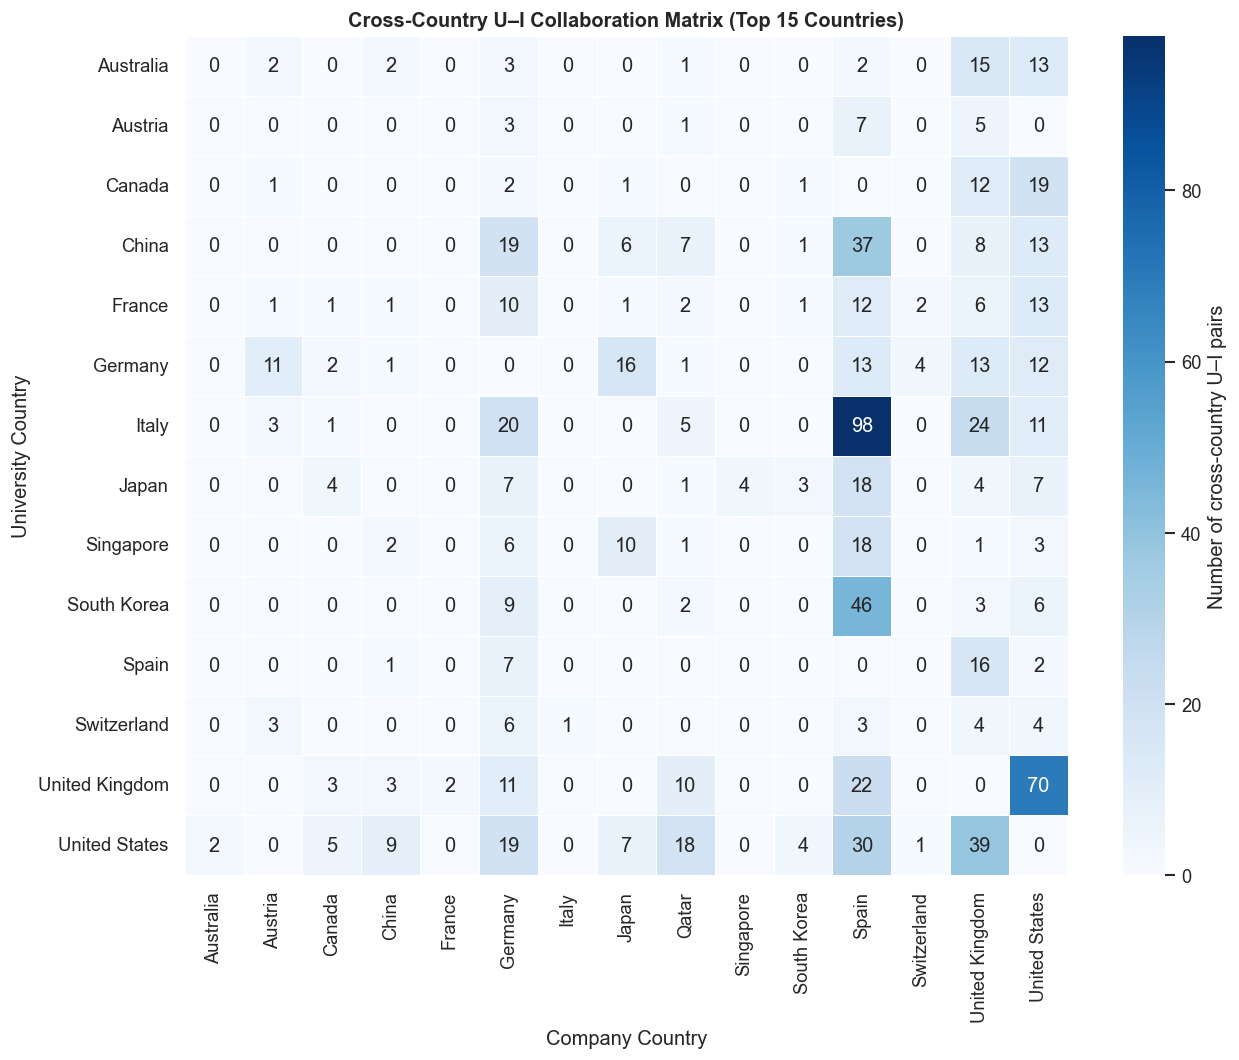

In [13]:
# Heatmap — top N countries
TOP_N = 15
top_n_countries = list(
    pd.concat([
        cross_counts['univ_country'],
        cross_counts['comp_country']
    ])
    .value_counts()
    .head(TOP_N)
    .index
)

filtered = cross_counts[
    cross_counts['univ_country'].isin(top_n_countries) &
    cross_counts['comp_country'].isin(top_n_countries)
]

matrix = filtered.pivot_table(
    index='univ_country', columns='comp_country',
    values='n_collabs', fill_value=0
)

matrix = matrix.astype(int)

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    matrix, cmap='Blues', annot=True, fmt='d',
    linewidths=0.4, ax=ax,
    cbar_kws={'label': 'Number of cross-country U–I pairs'}
)
ax.set_title(f'Cross-Country U–I Collaboration Matrix (Top {TOP_N} Countries)', fontweight='bold')
ax.set_xlabel('Company Country')
ax.set_ylabel('University Country')
plt.tight_layout()
plt.savefig('cross_country_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Collaboration Network Visualisation

We build a **country-level collaboration network** where nodes = countries and edge weight = number of cross-country U–I co-authored papers. This allows us to identify **knowledge hubs** and the structure of international knowledge spillovers.

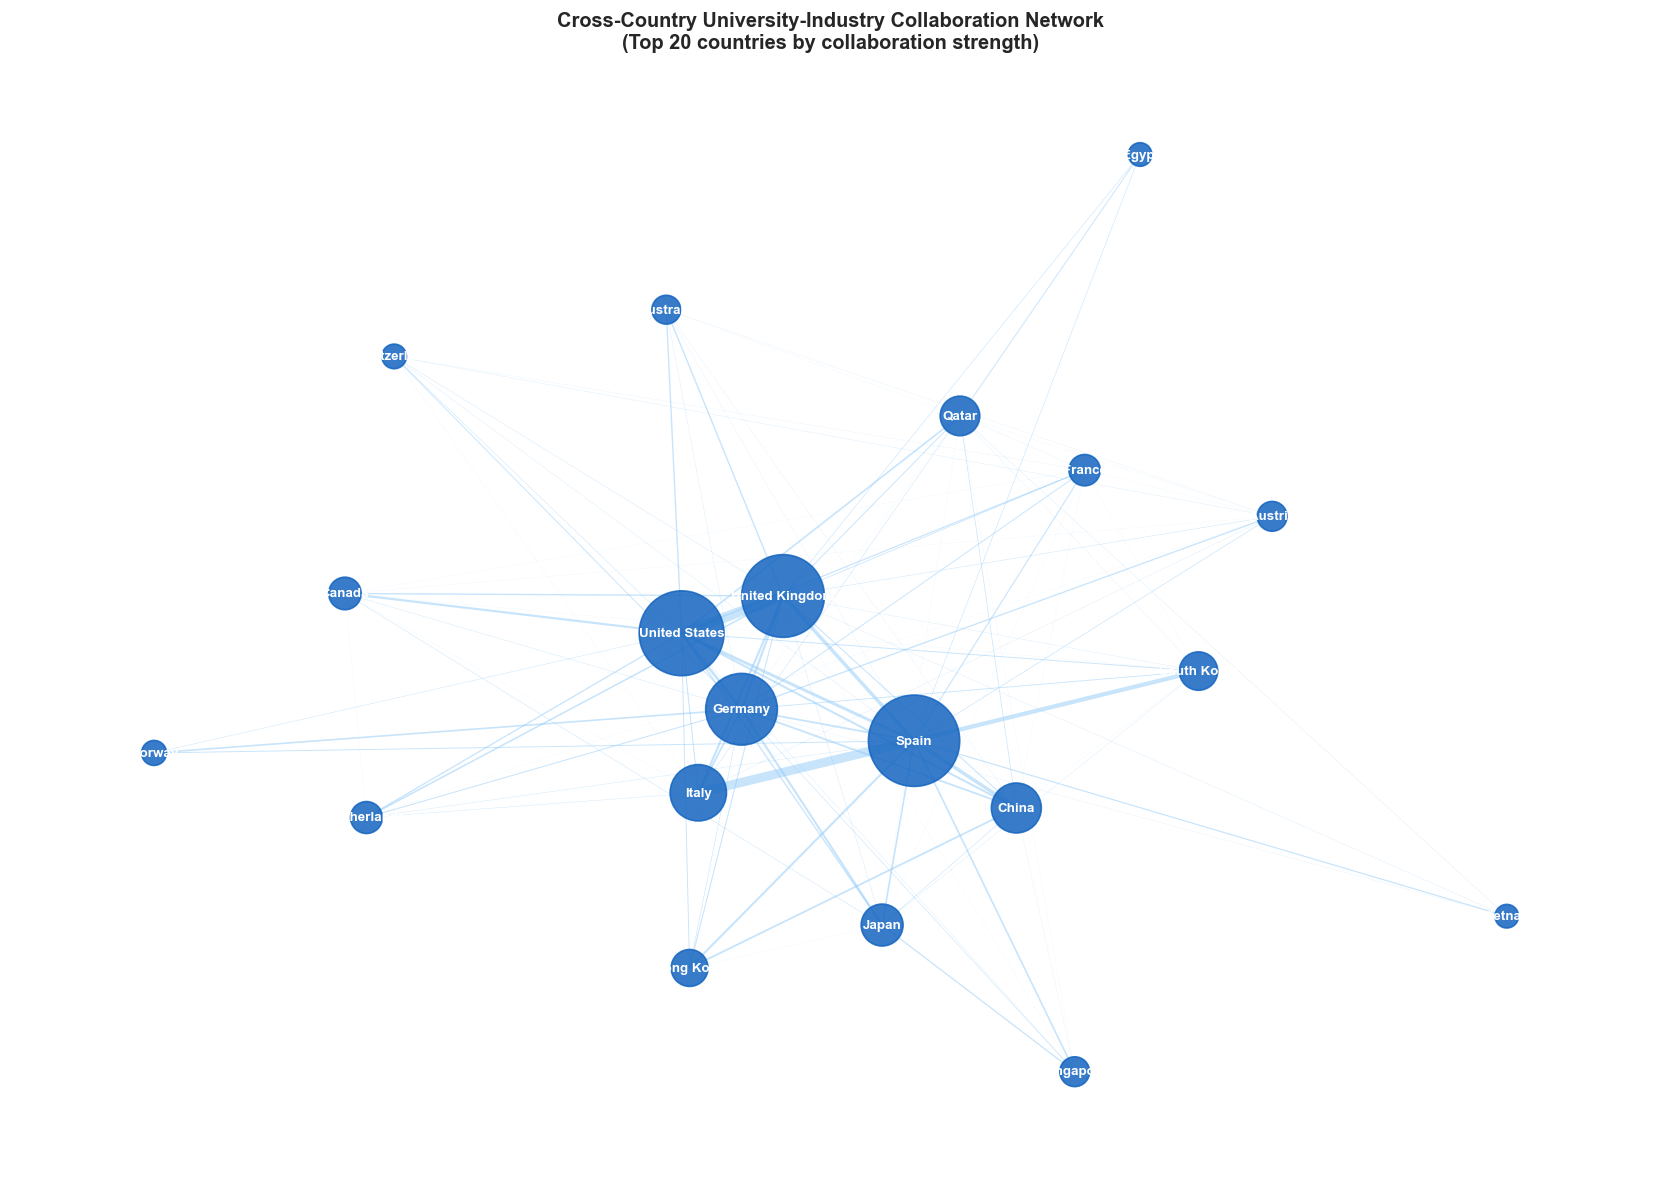

Network: 20 nodes, 98 edges


In [14]:
# Build undirected weighted graph
G = nx.Graph()

for _, row in cross_counts.iterrows():
    u, c, n = row['univ_country'], row['comp_country'], row['n_collabs']
    if G.has_edge(u, c):
        G[u][c]['weight'] += n
    else:
        G.add_edge(u, c, weight=n)

# Filter to top-N nodes by weighted degree
TOP_NODES = 20
node_strength = dict(nx.degree(G, weight='weight'))
top_nodes = sorted(node_strength, key=node_strength.get, reverse=True)[:TOP_NODES]
H = G.subgraph(top_nodes).copy()   # .copy() so we can use it safely

pos = nx.spring_layout(H, seed=42, k=2.5)

# Node sizes proportional to strength (minimum size guaranteed)
max_strength = max(node_strength.values()) if node_strength else 1
node_sizes = [max(node_strength.get(n, 1) / max_strength * 3000, 200) for n in H.nodes]

# Edge widths and alpha – guard against empty edge list
if H.number_of_edges() > 0:
    all_weights  = [H[u][v]['weight'] for u, v in H.edges]
    max_weight   = max(all_weights)
    edge_widths  = [w / max_weight * 6 for w in all_weights]
    edge_alpha_v = [min(w / max_weight + 0.15, 0.9) for w in all_weights]
else:
    edge_widths  = []
    edge_alpha_v = []

fig, ax = plt.subplots(figsize=(14, 10))
nx.draw_networkx_nodes(H, pos, node_size=node_sizes,
                       node_color='#1565C0', alpha=0.85, ax=ax)
nx.draw_networkx_labels(H, pos, font_size=8, font_color='white',
                        font_weight='bold', ax=ax)
if H.number_of_edges() > 0:
    nx.draw_networkx_edges(H, pos, width=edge_widths, alpha=0.5,
                           edge_color='#90CAF9', ax=ax)
ax.set_title(
    f'Cross-Country University-Industry Collaboration Network\n'
    f'(Top {TOP_NODES} countries by collaboration strength)',
    fontweight='bold'
)
ax.set_axis_off()
plt.tight_layout()
plt.savefig('collab_network.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Network: {H.number_of_nodes()} nodes, {H.number_of_edges()} edges')


## 9. Temporal Evolution of U–I Collaborations

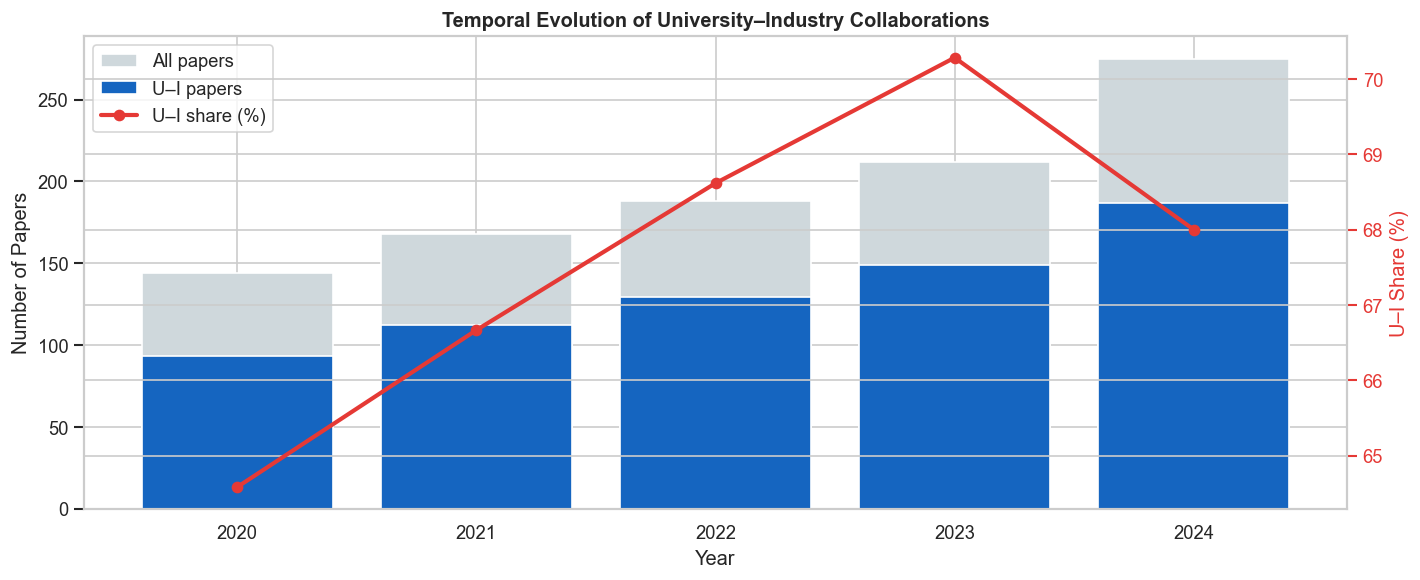

In [15]:
temporal = (
    df.groupby('Year')
    .agg(
        total_papers=('EID', 'count'),
        ui_papers=('ui_collab', 'sum')
    )
    .reset_index()
)
temporal['ui_share'] = temporal['ui_papers'] / temporal['total_papers'] * 100
# Only years with meaningful data
temporal = temporal[temporal['total_papers'] >= 10]

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.bar(temporal['Year'], temporal['total_papers'], color='#CFD8DC',
        label='All papers', zorder=1)
ax1.bar(temporal['Year'], temporal['ui_papers'], color='#1565C0',
        label='U–I papers', zorder=2)
ax2.plot(temporal['Year'], temporal['ui_share'], color='#E53935',
         linewidth=2.5, marker='o', label='U–I share (%)')

ax1.set_xlabel('Year')
ax1.set_ylabel('Number of Papers')
ax2.set_ylabel('U–I Share (%)', color='#E53935')
ax2.tick_params(axis='y', colors='#E53935')
ax1.set_title('Temporal Evolution of University–Industry Collaborations', fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('temporal_evolution.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Choropleth Maps

We use the Natural Earth world shapefile to map the geographic distribution of (a) all HealthTech papers and (b) U–I papers.

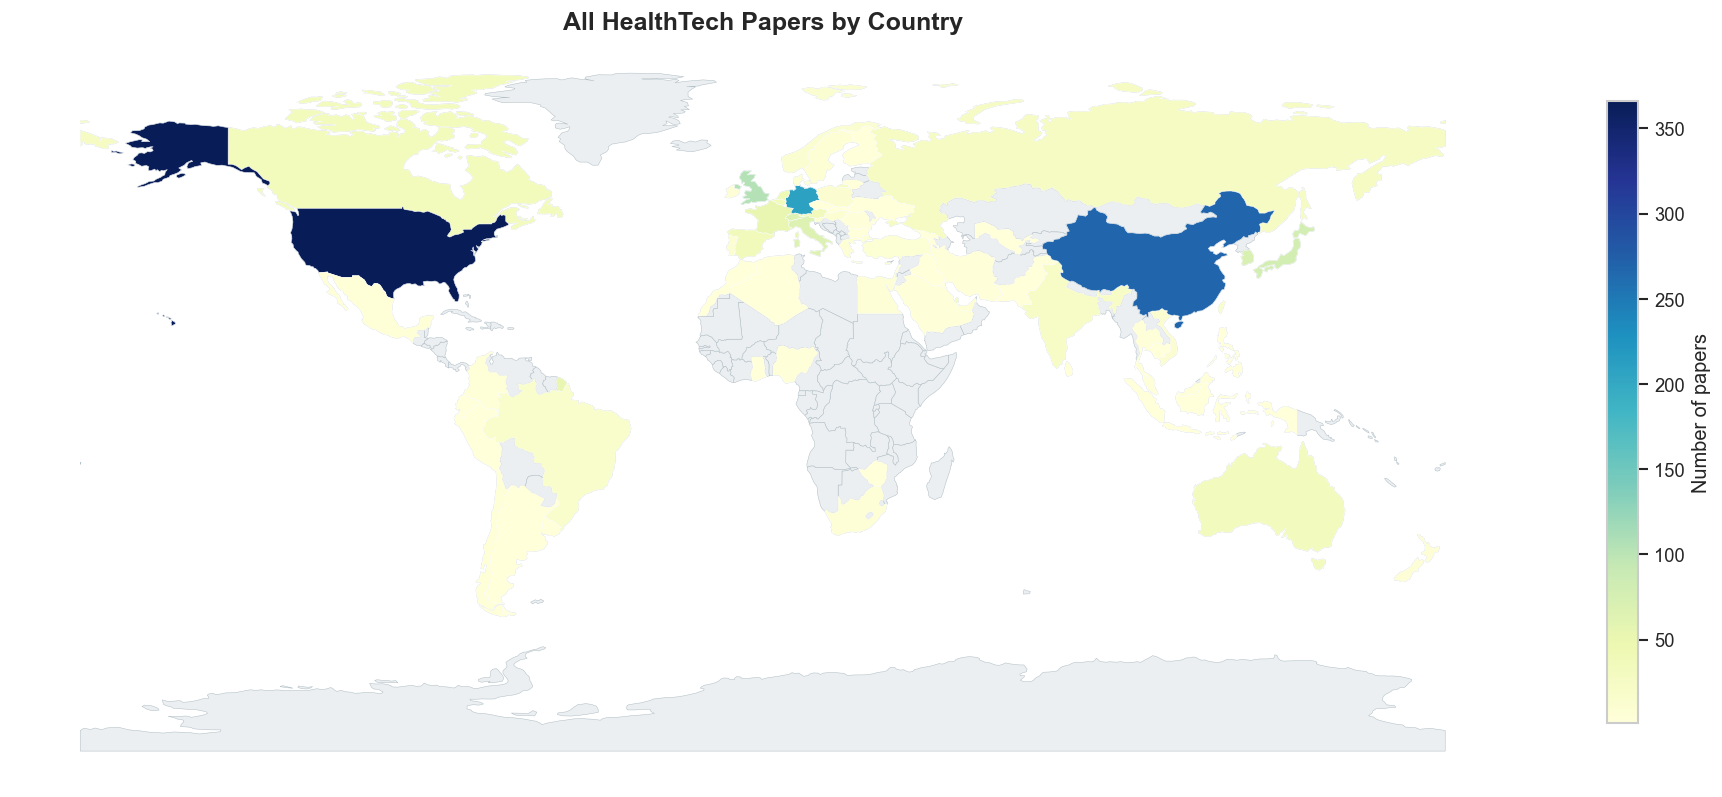

Map saved: map_total.png


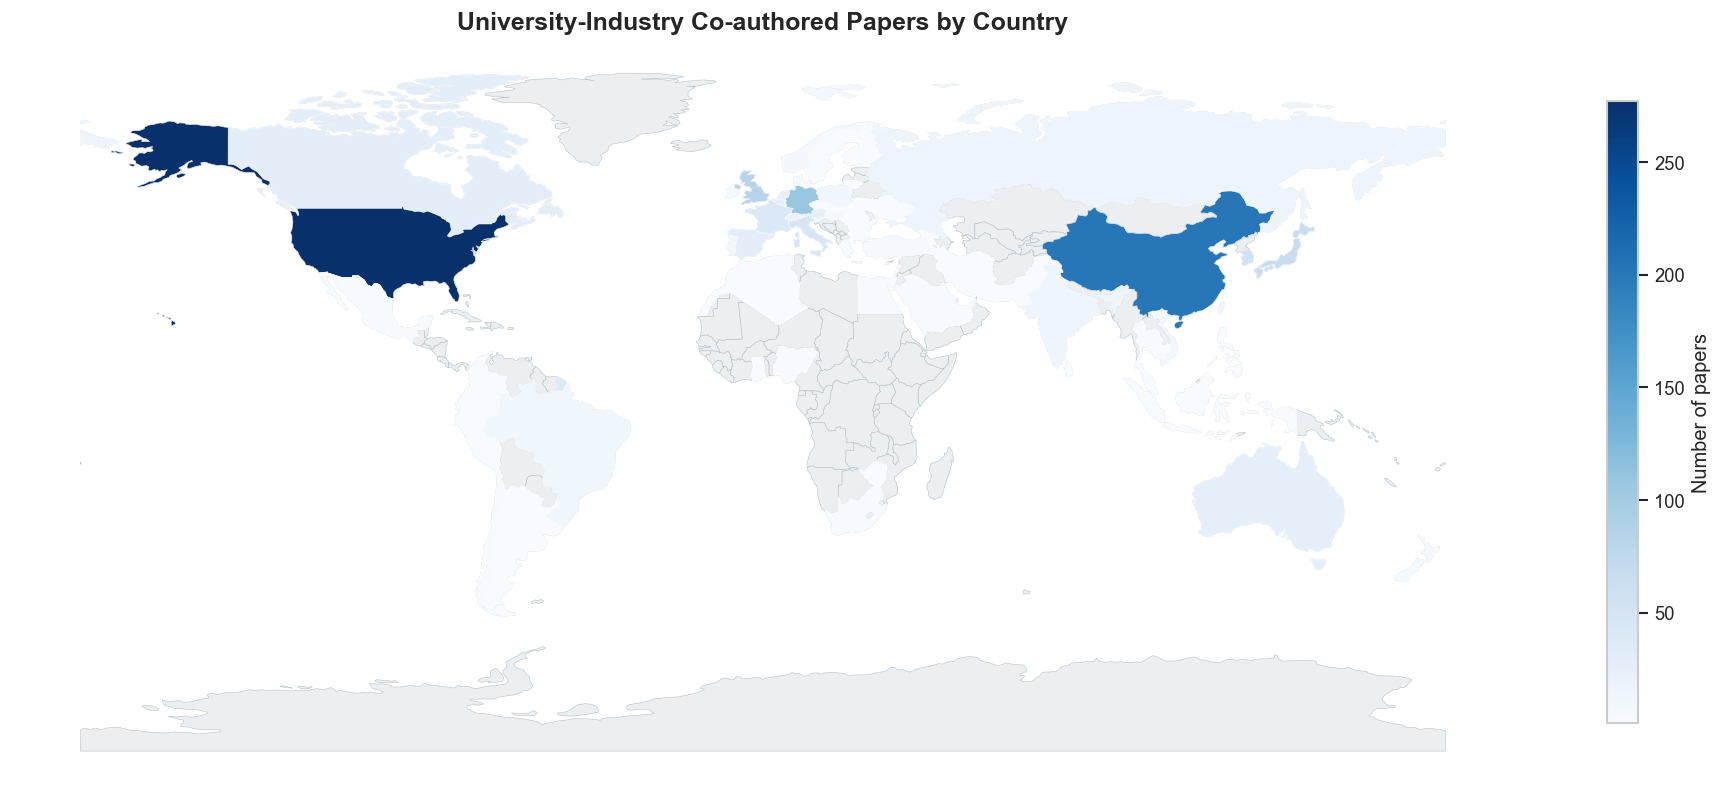

Map saved: map_ui.png


In [16]:
# Load world shapefile – compatible with geopandas >= 1.0

import geopandas as gpd

url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"

world = gpd.read_file(url)


def load_world_geodataframe():
    """Load Natural Earth low-res world polygons (geopandas >= 1.0 compatible)."""
    # Try new geodatasets package first (geopandas >= 1.0)
    try:
        import geodatasets
        path = geodatasets.get_path('naturalearth.countries')
        # naturalearth.land is polygons without country names; try countries below
    except Exception:
        pass

    try:
        import geodatasets
        path = geodatasets.get_path('naturalearth_lowres')
        return gpd.read_file(path)
    except Exception:
        pass

    # Fallback: use the file bundled inside geopandas package directory
    try:
        import geopandas as gpd_inner
        import os
        pkg_dir = os.path.dirname(gpd_inner.__file__)
        candidates = [
            os.path.join(pkg_dir, 'datasets', 'naturalearth_lowres', 'naturalearth_lowres.shp'),
            os.path.join(pkg_dir, 'datasets', 'naturalearth_lowres.shp'),
        ]
        for p in candidates:
            if os.path.exists(p):
                return gpd.read_file(p)
    except Exception:
        pass

    # Last resort: deprecated API (older geopandas)
    try:
        return gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
    except Exception:
        pass

    raise RuntimeError(
        'Cannot load Natural Earth shapefile. '
        'Install geodatasets: pip install geodatasets'
    )


world = gpd.read_file(
    "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
)

# Country name harmonisation to match our country_stats index
NAME_FIX = {
    'United States of America': 'United States',
    'Dem. Rep. Congo': 'Congo',
    'Bosnia and Herz.': 'Bosnia',
    'Czech Rep.': 'Czechia',
    'Dominican Rep.': 'Dominican Republic',
    'S. Korea': 'South Korea',
    'N. Korea': 'North Korea',
    'Korea': 'South Korea',
    'Falkland Is.': 'Falkland Islands',
    'Fr. S. Antarctic Lands': 'French Southern Territories',
}
world['ADMIN'] = world['ADMIN'].replace(NAME_FIX)

world_data = world.merge(
    country_stats.reset_index(),
    left_on='ADMIN', right_on='country', how='left'
)

# Fill NaN numeric columns
for col in ['papers_total', 'papers_ui', 'ui_share']:
    if col in world_data.columns:
        world_data[col] = world_data[col].fillna(0)


def plot_world_map(gdf, col, title, filename, cmap='Blues'):
    """Plot a choropleth world map for the given column."""
    fig, ax = plt.subplots(figsize=(16, 9))
    # Grey base for all countries
    world.plot(ax=ax, color='#ECEFF1', edgecolor='#B0BEC5', linewidth=0.3)
    # Coloured overlay for countries with data > 0
    mask = gdf[col].fillna(0) > 0
    if mask.any():
        gdf[mask].plot(
            column=col, ax=ax, cmap=cmap, legend=True,
            edgecolor='white', linewidth=0.3,
            legend_kwds={'label': 'Number of papers', 'shrink': 0.6}
        )
    ax.set_title(title, fontsize=15, fontweight='bold')
    ax.set_axis_off()
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Map saved: {filename}')


plot_world_map(world_data, 'papers_total',
               'All HealthTech Papers by Country', 'map_total.png', cmap='YlGnBu')
plot_world_map(world_data, 'papers_ui',
               'University-Industry Co-authored Papers by Country', 'map_ui.png', cmap='Blues')


## 11. Spatial Autocorrelation: Moran's I & LISA

We test whether U–I collaboration intensity is spatially clustered using Global Moran's I and Local Indicators of Spatial Association (LISA).

   GLOBAL MORAN'S I
  Moran's I  : 0.3446
  Expected I : -0.0057
  Z-score    : 7.3003
  P-value    : 0.0010
-> Significant POSITIVE spatial autocorrelation (clustering)


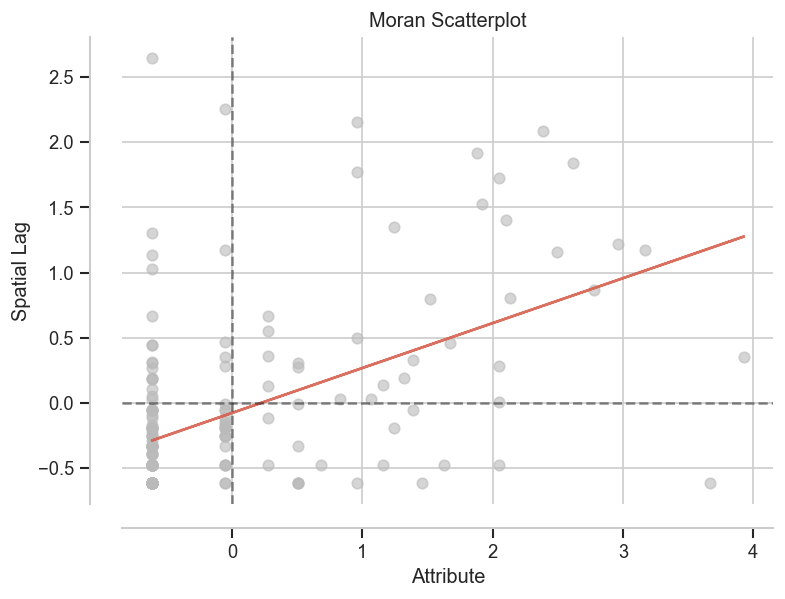

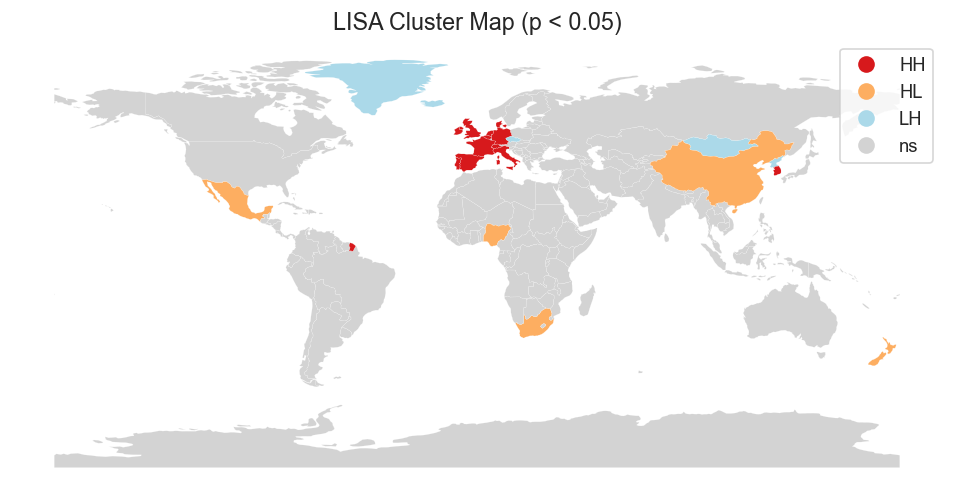


LISA Cluster Summary (significant only):
lisa_cluster
1    12
2     6
4     5
Name: count, dtype: int64


In [17]:
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt

from libpysal.weights import KNN
from esda.moran import Moran, Moran_Local
from splot.esda import moran_scatterplot, lisa_cluster


world_sub = world_data.copy()


world_sub['papers_ui'] = world_sub['papers_ui'].fillna(0).astype(float)

world_sub['papers_ui_log'] = np.log1p(world_sub['papers_ui'])


y = world_sub['papers_ui_log'].values

w = KNN.from_dataframe(world_sub, k=4)
w.transform = 'r'

moran = Moran(y, w, permutations=999)

print('=' * 45)
print("   GLOBAL MORAN'S I")
print('=' * 45)
print(f"  Moran's I  : {moran.I:.4f}")
print(f"  Expected I : {moran.EI:.4f}")
print(f"  Z-score    : {moran.z_sim:.4f}")
print(f"  P-value    : {moran.p_sim:.4f}")

if moran.p_sim < 0.05:
    if moran.I > moran.EI:
        print('-> Significant POSITIVE spatial autocorrelation (clustering)')
    else:
        print('-> Significant NEGATIVE spatial autocorrelation (dispersion)')
else:
    print('-> No significant spatial autocorrelation')


fig, ax = moran_scatterplot(moran)
ax.set_title("Moran Scatterplot", fontsize=12)
plt.show()


moran_loc = Moran_Local(y, w, permutations=999)

world_sub['lisa_I'] = moran_loc.Is
world_sub['lisa_p'] = moran_loc.p_sim
world_sub['lisa_cluster'] = moran_loc.q

sig = 0.05
world_sub['significant'] = world_sub['lisa_p'] < sig


fig, ax = plt.subplots(1, figsize=(10, 6))

lisa_cluster(moran_loc, world_sub, p=0.05, ax=ax)

ax.set_title("LISA Cluster Map (p < 0.05)", fontsize=14)
ax.set_axis_off()

plt.show()


print("\nLISA Cluster Summary (significant only):")
print(world_sub[world_sub['significant']]['lisa_cluster'].value_counts())

## 12. Proximity Effect: Same-Country vs. Cross-Country Citation Impact

Beyond mere counting, we test whether **home-bias collaborations** also produce more **highly-cited** papers — a proxy for the quality of knowledge spillovers.

In [18]:
from scipy import stats

cite_col = 'Cited by'
ui_valid = ui_df[ui_df['home_bias'].notna() & ui_df[cite_col].notna()].copy()
ui_valid[cite_col] = pd.to_numeric(ui_valid[cite_col], errors='coerce')
ui_valid = ui_valid.dropna(subset=[cite_col])

same    = ui_valid[ui_valid['home_bias'] == True][cite_col]
cross   = ui_valid[ui_valid['home_bias'] == False][cite_col]

print('=== CITATION IMPACT: HOME-BIAS vs. CROSS-COUNTRY ===')
print(f'  Same-country  — N={len(same):>4}, Median={same.median():.1f}, Mean={same.mean():.1f}')
print(f'  Cross-country — N={len(cross):>4}, Median={cross.median():.1f}, Mean={cross.mean():.1f}')

if len(same) > 5 and len(cross) > 5:
    stat, pval = stats.mannwhitneyu(same, cross, alternative='two-sided')
    print(f'  Mann-Whitney U: stat={stat:.1f}, p={pval:.4f}')
    if pval < 0.05:
        winner = 'same-country' if same.median() > cross.median() else 'cross-country'
        print(f'→ Statistically significant difference: {winner} papers are more cited.')
    else:
        print('→ No statistically significant difference in citation impact.')

=== CITATION IMPACT: HOME-BIAS vs. CROSS-COUNTRY ===
  Same-country  — N= 559, Median=7.0, Mean=16.3
  Cross-country — N= 103, Median=8.0, Mean=15.1
  Mann-Whitney U: stat=28474.5, p=0.8602
→ No statistically significant difference in citation impact.


## 13. Summary & Conclusions

This cell auto-generates a textual summary based on the actual numbers computed above.

In [19]:
print('=' * 60)
print('  CHAPTER 2 SUMMARY — PROXIMITY & KNOWLEDGE SPILLOVERS')
print('=' * 60)
print()
print(f'Dataset: {len(df):,} HealthTech publications from Scopus')
print()
print('1. UNIVERSITY-INDUSTRY COLLABORATION INCIDENCE')
print(f'   {df["ui_collab"].sum():,} papers ({df["ui_collab"].mean()*100:.1f}%) involve'
      f' at least one university and one company.')
print()
print('2. HOME-BIAS TEST (core hypothesis)')
print(f'   {pct_same:.1f}% of U-I papers share the same country between'
      f' university and company authors.')
if pct_same > 60:
    print('   -> Strong home bias confirmed: proximity lowers the cost')
    print('      of collaboration and tacit knowledge transfer.')
else:
    print('   -> Home bias is moderate: internationalisation of R&D')
    print('      may weaken the proximity effect in HealthTech.')
print()
print('3. SPATIAL CONCENTRATION (Moran\'s I)')
if 'moran' in dir():
    print(f'   I = {moran.I:.3f}, p = {moran.p_sim:.3f}', end=' ')
    if moran.p_sim < 0.05 and moran.I > 0:
        print('-> Significant positive spatial clustering.')
    else:
        print('-> No significant global spatial clustering.')
else:
    print('   Spatial analysis not run (geopandas/libpysal not available).')
print()
print('4. MAIN KNOWLEDGE HUBS')
print('   Top countries by U-I papers:')
for c, row_s in country_stats.head(5).iterrows():
    print(f'   - {c:<22} {int(row_s["papers_ui"]):>4} U-I papers')
print()
print('5. POLICY IMPLICATION')
print('   The strong home bias and spatial clustering suggest that')
print('   regional innovation policies and local science parks remain')
print('   the most effective lever for boosting U-I knowledge transfer.')


  CHAPTER 2 SUMMARY — PROXIMITY & KNOWLEDGE SPILLOVERS

Dataset: 987 HealthTech publications from Scopus

1. UNIVERSITY-INDUSTRY COLLABORATION INCIDENCE
   670 papers (67.9%) involve at least one university and one company.

2. HOME-BIAS TEST (core hypothesis)
   84.4% of U-I papers share the same country between university and company authors.
   -> Strong home bias confirmed: proximity lowers the cost
      of collaboration and tacit knowledge transfer.

3. SPATIAL CONCENTRATION (Moran's I)
   I = 0.345, p = 0.001 -> Significant positive spatial clustering.

4. MAIN KNOWLEDGE HUBS
   Top countries by U-I papers:
   - United States           277 U-I papers
   - China                   201 U-I papers
   - Germany                 108 U-I papers
   - United Kingdom           83 U-I papers
   - Japan                    66 U-I papers

5. POLICY IMPLICATION
   The strong home bias and spatial clustering suggest that
   regional innovation policies and local science parks remain
   the most 